In [127]:
import numpy as np
import os
import xarray as xr
import glob
import re
import matplotlib.pyplot as plt
import pickle
from scipy import stats, interpolate
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 3 phases

In [130]:
filepaths_1 = [f'/glade/derecho/scratch/cassiacai/vertical_phases/ds_temp_data_3phase_0320_ls{i}.nc' for i in range(0, 68)]
filepaths_2 = [f'/glade/derecho/scratch/cassiacai/vertical_phases/ds_temp_data_3phase_0319_ls{i}.nc' for i in range(68, 100)]
filepaths = filepaths_1 + filepaths_2
ds_3phases_temp = xr.open_mfdataset(filepaths, 
                                    combine='nested', 
                                    concat_dim='mhw_event_ind').__xarray_dataarray_variable__.compute()

filepaths_1 = [f'/glade/derecho/scratch/cassiacai/vertical_phases/ds_mld_data_3phase_0320_ls{i}.nc' for i in range(0, 68)]
filepaths_2 = [f'/glade/derecho/scratch/cassiacai/vertical_phases/ds_mld_data_3phase_0319_ls{i}.nc' for i in range(68, 100)]
filepaths = filepaths_1 + filepaths_2
ds_3phases_mld = xr.open_mfdataset(filepaths, 
                                   combine='nested', 
                                   concat_dim='mhw_event_ind').__xarray_dataarray_variable__.compute()

## 5 phases

In [221]:
filepaths_1 = [f'/glade/derecho/scratch/cassiacai/vertical_phases/ds_temp_data_5phase_0320_ls{i}.nc' for i in range(0, 68)]
filepaths_2 = [f'/glade/derecho/scratch/cassiacai/vertical_phases/ds_temp_data_5phase_0319_ls{i}.nc' for i in range(68, 100)]
filepaths = filepaths_1 + filepaths_2

ds_5phases_temp_p1 = xr.open_mfdataset(filepaths[:62], 
                                    combine='nested', 
                                    concat_dim='mhw_event_ind').__xarray_dataarray_variable__.compute()

ds_5phases_temp_p2 = xr.open_dataset(
    '/glade/derecho/scratch/cassiacai/vertical_phases/ds_temp_data_5phase_0320_ls62.nc').__xarray_dataarray_variable__.compute()

ds_5phases_temp_p3 = xr.open_mfdataset(filepaths[63:100], 
                                    combine='nested', 
                                    concat_dim='mhw_event_ind').__xarray_dataarray_variable__.compute()

ds_5phases_temp = xr.concat([ds_5phases_temp_p1,ds_5phases_temp_p2, ds_5phases_temp_p3], 
          dim='mhw_event_ind')

In [222]:
filepaths_1 = [f'/glade/derecho/scratch/cassiacai/vertical_phases/ds_mld_data_5phase_0320_ls{i}.nc' for i in range(0, 68)]
filepaths_2 = [f'/glade/derecho/scratch/cassiacai/vertical_phases/ds_mld_data_5phase_0319_ls{i}.nc' for i in range(68, 100)]
filepaths = filepaths_1 + filepaths_2

ds_5phases_mld_p1 = xr.open_mfdataset(filepaths[:62], 
                                    combine='nested', 
                                    concat_dim='mhw_event_ind').__xarray_dataarray_variable__.compute()

ds_5phases_mld_p2 = xr.open_dataset(
    '/glade/derecho/scratch/cassiacai/vertical_phases/ds_mld_data_5phase_0320_ls62.nc').__xarray_dataarray_variable__.compute()

ds_5phases_mld_p3 = xr.open_mfdataset(filepaths[63:100], 
                                    combine='nested', 
                                    concat_dim='mhw_event_ind').__xarray_dataarray_variable__.compute()

ds_5phases_mld = xr.concat([ds_5phases_mld_p1,ds_5phases_mld_p2, ds_5phases_mld_p3], 
          dim='mhw_event_ind')

In [319]:
filepaths = [f'/glade/derecho/scratch/cassiacai/vertical_phases/new_depth_phase_data{i}.pkl' for i in range(0, 100)]
sorted_filepaths = sorted(filepaths, key=lambda x: int(re.search(r'depth_phase_data(\d+)', x).group(1)))

all_data = []
for fp in sorted_filepaths:
    with open(fp, 'rb') as f:
        data = pickle.load(f)
        all_data.append(data)

In [497]:
depth_indx_tempmax = []
for ens_memb in range((100)):
    for sublist_len in all_data[ens_memb]:
        # print(sublist_len)
        # print(np.mean(sublist_len[2:-2]).item())
        # depth_indx_tempmax.append(np.max(sublist_len[2:-2]).item())
        depth_indx_tempmax.append(np.nanmean(sublist_len[2:-2]).item())

In [498]:
# depth_indx_tempmax = []

# for ens_memb in range(100):
#     for sublist_len in all_data[ens_memb]:
#         sliced = sublist_len[2:-2]
#         if len(sliced) > 0:
#             depth_indx_tempmax.append(np.nanmax(sliced).item())
#         else:
#             depth_indx_tempmax.append(np.nan)

# depth_indx_tempmax = np.array(depth_indx_tempmax)

In [499]:
depths = ds_5phases_temp_p3.z_t

In [500]:
rounded_depth_indx=np.round(depth_indx_tempmax).astype(int)

In [501]:
temp_depthval_ls = []
for i in range(407):
    indx = rounded_depth_indx[i]
    if indx >= 0:
        temp_depthval = depths[indx]
        temp_depthval_ls.append(temp_depthval.item())
    else:
        temp_depthval_ls.append(np.nan)

In [502]:
corresponding_depths = np.asarray(temp_depthval_ls)/100

Total valid points: 406
Depth range: 5.0 to 85.0 m


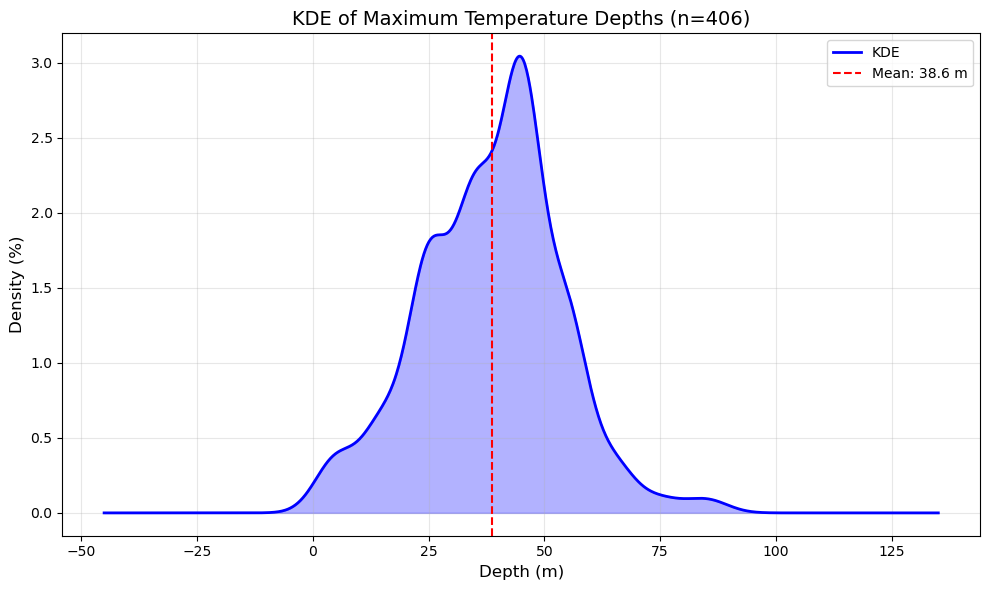


Statistics:
Mean depth: 38.6 m
Median depth: 45.0 m
Std dev: 14.9 m
Total area under curve: 100.00%


In [503]:
# Your depths data (filter out NaNs)
depths_clean = corresponding_depths[~np.isnan(corresponding_depths)]

print(f"Total valid points: {len(depths_clean)}")
print(f"Depth range: {depths_clean.min():.1f} to {depths_clean.max():.1f} m")

# Create KDE
kde = stats.gaussian_kde(depths_clean)

# Create range for plotting
x_range = np.linspace(depths_clean.min() - 50, depths_clean.max() + 50, 1000)
kde_values = kde(x_range)

# Calculate area under KDE
area = np.trapz(kde_values, x_range)

# Convert to percentage
kde_percent = kde_values / area * 100

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_range, kde_percent, 'b-', linewidth=2, label='KDE')
plt.fill_between(x_range, kde_percent, alpha=0.3, color='blue')

# Add vertical line at mean
mean_depth = depths_clean.mean()
plt.axvline(mean_depth, color='red', linestyle='--', linewidth=1.5, 
            label=f'Mean: {mean_depth:.1f} m')

plt.xlabel('Depth (m)', fontsize=12)
plt.ylabel('Density (%)', fontsize=12)
plt.title(f'KDE of Maximum Temperature Depths (n={len(depths_clean)})', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nStatistics:")
print(f"Mean depth: {mean_depth:.1f} m")
print(f"Median depth: {np.median(depths_clean):.1f} m")
print(f"Std dev: {depths_clean.std():.1f} m")
print(f"Total area under curve: {np.trapz(kde_percent, x_range):.2f}%")

In [504]:
# Your data
data_clean = corresponding_depths[~np.isnan(corresponding_depths)]
min_kde = 5.0
max_kde = 200.
data_for_kde = data_clean[data_clean >= min_kde]
data_for_kde = data_for_kde[data_for_kde <= max_kde]

print(f"Total data points: {len(data_clean)}")
print(f"Points ≥ {min_kde}m: {len(data_for_kde)}")

# Create KDE
kde = stats.gaussian_kde(data_for_kde)

# Create x values for KDE calculation
x_kde_min = min_kde
x_kde_max = data_for_kde.max() * 1.1
x_kde_range = np.linspace(x_kde_min, x_kde_max, 1000)

# Calculate KDE values
kde_values = kde(x_kde_range)

# **CRITICAL: Calculate area under KDE from min_kde to infinity**
# Use KDE's built-in integration
area_truncated = kde.integrate_box_1d(min_kde, np.inf)
print(f"Area under KDE from {min_kde}m to ∞: {area_truncated:.6f}")

# Normalize the KDE for the truncated region
kde_values_normalized = kde_values / area_truncated

# Convert to percentage
kde_percent = kde_values_normalized * 100

# Create full plotting range
x_plot = np.linspace(0, x_kde_max, 1000)
kde_plot = np.zeros_like(x_plot)

# Interpolate
mask = x_plot >= min_kde
interp_func = interpolate.interp1d(x_kde_range, kde_percent, 
                                   bounds_error=False, fill_value=0)
kde_plot[mask] = interp_func(x_plot[mask])

# Calculate final area
total_area = np.trapz(kde_plot, x_plot)
print(f"Area under plotted curve: {total_area:.2f}%")

Total data points: 406
Points ≥ 5.0m: 406
Area under KDE from 5.0m to ∞: 0.979488
Area under plotted curve: 99.97%


In [505]:
np.nanmean(corresponding_depths)
np.nanstd(corresponding_depths)

np.float64(14.934153808858854)

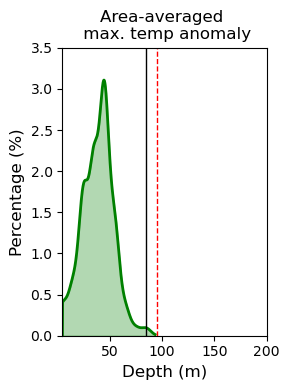

In [506]:
# Plot
plt.figure(figsize=(3, 4))
plt.plot(x_plot, kde_plot, 'g-', linewidth=2)
plt.fill_between(x_plot, kde_plot, alpha=0.3, color='green')
plt.title('Area-averaged \n max. temp anomaly', fontsize=12)
plt.xlabel('Depth (m)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
# plt.grid(True, alpha=0.3)
plt.xlim(5, 200)
plt.ylim(0, 3.5)
plt.tight_layout()
plt.axvline(x=95, c='red', linestyle='dashed', linewidth=1)
plt.axvline(x=85, c='k', linewidth=1)

plt.show()

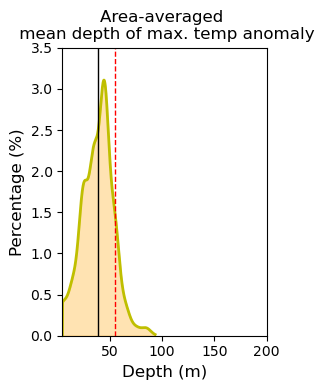

In [507]:
# Plot
plt.figure(figsize=(3, 4))
plt.plot(x_plot, kde_plot, 'y-', linewidth=2)
plt.fill_between(x_plot, kde_plot, alpha=0.3, color='orange')
plt.title('Area-averaged \n mean depth of max. temp anomaly', fontsize=12)
plt.xlabel('Depth (m)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
# plt.grid(True, alpha=0.3)
plt.xlim(5, 200)
plt.ylim(0, 3.5)
plt.tight_layout()
plt.axvline(x=55, c='red', linestyle='dashed', linewidth=1)
plt.axvline(x=39, c='k', linewidth=1)

plt.show()

In [508]:
def calculate_kde_area(x_values, y_values, x_min=None, x_max=None):
    """
    Calculate area under KDE curve between specified limits.
    
    Parameters:
    -----------
    x_values, y_values: arrays for KDE curve
    x_min, x_max: integration limits (use data min/max if None)
    
    Returns:
    --------
    area: float, area under curve
    """
    if x_min is None:
        x_min = x_values.min()
    if x_max is None:
        x_max = x_values.max()
    
    # Filter values within range
    mask = (x_values >= x_min) & (x_values <= x_max)
    if not np.any(mask):
        return 0.0
    
    x_filtered = x_values[mask]
    y_filtered = y_values[mask]
    
    # Integrate
    area = np.trapz(y_filtered, x_filtered)
    return area

In [509]:
# Calculate areas for your specified bins
area_0_to_20 = calculate_kde_area(x_plot, kde_plot, x_min=0, x_max=20)
area_20_to_40 = calculate_kde_area(x_plot, kde_plot, x_min=20, x_max=40)
area_40_to_60 = calculate_kde_area(x_plot, kde_plot, x_min=40, x_max=60)
area_60_to_80 = calculate_kde_area(x_plot, kde_plot, x_min=60, x_max=80)
area_80_to_100 = calculate_kde_area(x_plot, kde_plot, x_min=80, x_max=100)
area_100_to_120 = calculate_kde_area(x_plot, kde_plot, x_min=100, x_max=120)
area_120_to_140 = calculate_kde_area(x_plot, kde_plot, x_min=120, x_max=140)
area_140_to_160 = calculate_kde_area(x_plot, kde_plot, x_min=140, x_max=160)
area_160_to_180 = calculate_kde_area(x_plot, kde_plot, x_min=160, x_max=180)
area_180_to_200 = calculate_kde_area(x_plot, kde_plot, x_min=180, x_max=200)
area_200_plus = calculate_kde_area(x_plot, kde_plot, x_min=200)

# Print results
print(f"Total area (0-∞): {total_area:.2f}%")
print("\nDepth distribution:")
print(f"0-20m: {area_0_to_20:.2f}% ({area_0_to_20/total_area*100:.1f}% of total)")
print(f"20-40m: {area_20_to_40:.2f}% ({area_20_to_40/total_area*100:.1f}% of total)")
print(f"40-60m: {area_40_to_60:.2f}% ({area_40_to_60/total_area*100:.1f}% of total)")
print(f"60-80m: {area_60_to_80:.2f}% ({area_60_to_80/total_area*100:.1f}% of total)")
print(f"80-100m: {area_80_to_100:.2f}% ({area_80_to_100/total_area*100:.1f}% of total)")
print(f"100-120m: {area_100_to_120:.2f}% ({area_100_to_120/total_area*100:.1f}% of total)")
print(f"120-140m: {area_120_to_140:.2f}% ({area_120_to_140/total_area*100:.1f}% of total)")
print(f"140-160m: {area_140_to_160:.2f}% ({area_140_to_160/total_area*100:.1f}% of total)")
print(f"160-180m: {area_160_to_180:.2f}% ({area_160_to_180/total_area*100:.1f}% of total)")
print(f"180-200m: {area_180_to_200:.2f}% ({area_180_to_200/total_area*100:.1f}% of total)")
print(f">200m: {area_200_plus:.2f}% ({area_200_plus/total_area*100:.1f}% of total)")

Total area (0-∞): 99.97%

Depth distribution:
0-20m: 9.75% (9.8% of total)
20-40m: 39.83% (39.8% of total)
40-60m: 43.10% (43.1% of total)
60-80m: 5.86% (5.9% of total)
80-100m: 0.98% (1.0% of total)
100-120m: 0.00% (0.0% of total)
120-140m: 0.00% (0.0% of total)
140-160m: 0.00% (0.0% of total)
160-180m: 0.00% (0.0% of total)
180-200m: 0.00% (0.0% of total)
>200m: 0.00% (0.0% of total)


In [510]:
area_55_to_200 = calculate_kde_area(x_plot, kde_plot, x_min=95, x_max=200)
print(f"0-20m: {area_55_to_200:.2f}% ({area_55_to_200/total_area*100:.1f}% of total)")


0-20m: 0.00% (0.0% of total)


In [511]:
indices = np.where((corresponding_depths >= 80) & (corresponding_depths < 100))[0]
print(len(indices))

4


In [387]:
ds_3phases_mld_nan = xr.where(ds_3phases_mld == 0., np.nan, ds_3phases_mld)
ds_3phases_temp_nan = xr.where(ds_3phases_temp == 0., np.nan, ds_3phases_temp)

In [388]:
data = ds_3phases_temp_nan[indices].mean(dim='mhw_event_ind')
data_mld = ds_3phases_mld_nan[indices].mean(dim='mhw_event_ind').compute()

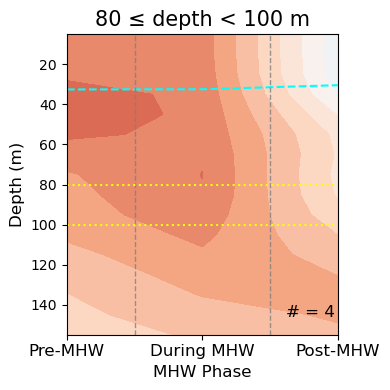

In [391]:
fig, ax = plt.subplots(figsize=(4, 4))

contour = data.transpose().plot.contourf(
    ax=ax,
    yincrease=False,
    cmap='RdBu_r',
    robust=True,
    levels=25, 
    vmin=-0.5, vmax=0.5,
    add_colorbar=False
)

data_mld.plot(c='cyan', linestyle='dashed')
for x in [0.5, 1.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)

ax.set_xticks([0., 1., 2,])
ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=12)

ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000])
ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200], fontsize=10)
ax.set_xlabel("MHW Phase", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)

# Layout and limits
plt.ylim(15500, 500)
# plt.title('>100m', fontsize=15)

plt.title('80 ≤ depth < 100 m', fontsize=15)
plt.text(0.99, 0.1, '# = {}'.format(len(indices)), transform=ax.transAxes, 
         fontsize=12, ha='right', va='top')
plt.axhline(y=8000, c='yellow', linestyle='dotted')
plt.axhline(y=10000, c='yellow', linestyle='dotted')
plt.tight_layout()
plt.show()

In [392]:
ds_5phases_mld_nan = xr.where(ds_5phases_mld == 0., np.nan, ds_5phases_mld)
ds_5phases_temp_nan = xr.where(ds_5phases_temp == 0., np.nan, ds_5phases_temp)

In [393]:
data = ds_5phases_temp_nan[indices].mean(dim='mhw_event_ind')
data_mld = ds_5phases_mld_nan[indices].mean(dim='mhw_event_ind').compute()

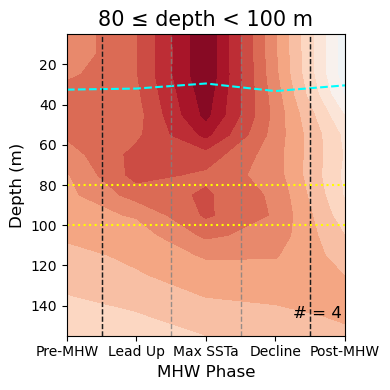

In [397]:
fig, ax = plt.subplots(figsize=(4, 4))

contour = data.transpose().plot.contourf(
    ax=ax,
    yincrease=False,
    cmap='RdBu_r',
    robust=True,
    levels=25, 
    vmin=-0.5, vmax=0.5,
    add_colorbar=False
)
# for x in [0.5, 1.5]:
#     ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)

# ax.set_xticks([0., 1., 2,])
# ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=12)
data_mld.plot(c='cyan', linestyle='dashed')

for x in [0.5, 1.5, 2.5, 3.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)

for x in [0.5, 3.5]:
    ax.axvline(x, color='k', linestyle='--', linewidth=1., alpha=0.8)

ax.set_xticks([0., 1., 2,3, 4])
ax.set_xticklabels(["Pre-MHW", "Lead Up", "Max SSTa", "Decline", "Post-MHW"], fontsize=10)


ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000])
ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200], fontsize=10)
ax.set_xlabel("MHW Phase", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)

# Layout and limits
plt.ylim(15500, 500)
# plt.title('>100m', fontsize=15)
plt.axhline(y=8000, c='yellow', linestyle='dotted')
plt.axhline(y=10000, c='yellow', linestyle='dotted')
plt.title('80 ≤ depth < 100 m', fontsize=15)
plt.text(0.99, 0.1, '# = {}'.format(len(indices)), transform=ax.transAxes, 
         fontsize=12, ha='right', va='top')
plt.tight_layout()
plt.show()